# 📥 Guía Práctica: Obtener Datos Financieros desde Yahoo Finance

**Curso:** Manejo de Datos · Actuaría  
**Nivel:** Intermedio (conocimiento básico de pandas)

---

### ¿Qué vas a aprender en este notebook?

Al terminar de seguir esta guía paso a paso serás capaz de:

- ✅ Entender qué es Yahoo Finance y por qué lo usamos
- ✅ Buscar el ticker correcto de cualquier acción o ETF
- ✅ Descargar precios históricos con `yfinance`
- ✅ Explorar, limpiar y guardar los datos
- ✅ Obtener información adicional: dividendos, splits, info de la empresa


---
## 🧩 Parte 1: ¿Qué es Yahoo Finance y cómo funciona `yfinance`?

**Yahoo Finance** es una de las fuentes de datos financieros más grandes y gratuitas del mundo. Puedes consultar precios históricos, noticias, estados financieros y mucho más.

La librería **`yfinance`** es un wrapper de Python que nos permite descargar esos datos directamente desde nuestro código — sin necesidad de registrarse, sin API key, completamente gratis.

```
Tu código Python
      ↓
   yfinance          (librería de Python)
      ↓
Yahoo Finance API    (servidores de Yahoo)
      ↓
DataFrame de pandas  (listo para analizar)
```

### ¿Qué es un ticker?

Un **ticker** es el código único que identifica a una acción en bolsa. Es como el CURP de la empresa en el mercado financiero.

| Empresa | Bolsa | Ticker |
|---------|-------|--------|
| Apple | NASDAQ (EE.UU.) | `AAPL` |
| Microsoft | NASDAQ (EE.UU.) | `MSFT` |
| S&P 500 ETF | NYSE (EE.UU.) | `SPY` |
| Walmart México | BMV (México) | `WALMEX.MX` |
| América Móvil | BMV (México) | `AMXL.MX` |
| Bono del Tesoro EE.UU. 10 años | — | `^TNX` |
| Oro (futuros) | COMEX | `GC=F` |
| Bitcoin | Crypto | `BTC-USD` |

> 🇲🇽 **Regla para México:** agrega `.MX` al símbolo de la BMV. Búscalo en [bmv.com.mx](https://www.bmv.com.mx)

---
## 🔧 Parte 2: Instalación y configuración inicial

In [1]:
# ─── Paso 1: Instalar yfinance ────────────────────────────────────────────────

# El signo ! le dice a Jupyter que ejecute un comando del sistema operativo.

!pip install yfinance --quiet
print("yfinance instalado")

yfinance instalado


In [2]:
# ─── Paso 2: Importar las librerías  ─────────────────────────────

import yfinance as yf          # Para descargar datos de Yahoo Finance
import pandas as pd            # Para manipular datos en tablas (DataFrames)
import numpy as np             # Para operaciones matemáticas
import matplotlib.pyplot as plt  # Para graficar
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
pd.set_option('display.float_format', '{:.4f}'.format)  # Pandas solo muestra 4 decimales en las tablas
pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-darkgrid')

print(f"Librerías importadas")
print(f"   yfinance versión: {yf.__version__}")
print(f"   pandas  versión: {pd.__version__}")

Librerías importadas
   yfinance versión: 1.3.0
   pandas  versión: 2.2.3


---
## 📡 Parte 3: Tu primera descarga 

El método principal es `yf.download()`. Sus parámetros más importantes son:

| Parámetro | Tipo | Descripción | Ejemplo |
|-----------|------|-------------|--------|
| `tickers` | str o lista | Ticker(s) a descargar | `"AAPL"` |
| `start` | str | Fecha de inicio `YYYY-MM-DD` | `"2020-01-01"` |
| `end` | str | Fecha de fin `YYYY-MM-DD` | `"2024-12-31"` |
| `period` | str | Período predefinido | `"1y"`, `"5y"`, `"max"` |
| `interval` | str | Frecuencia de los datos | `"1d"`, `"1wk"`, `"1mo"` |
| `auto_adjust` | bool | Ajusta por dividendos/splits | `True` (recomendado) |

> ⚠️ Usa `start`/`end` **O** `period` — no ambos al mismo tiempo.

In [3]:

# ─── Descargando Apple (AAPL) — últimos 5 años ───────────────────────────────

print("⏳ Descargando datos de AAPL...")

aapl = yf.download(
    tickers      = "AAPL",
    start        = "2019-01-01",
    end          = "2024-12-31",
    auto_adjust  = True,   # Precios ajustados (se recomenda para análisis)
    progress     = False
)

print ()
print(f"Descarga exitosa")
print ()
print(f"   -> Filas (días de trading): {len(aapl):,}")
print ()
print(f"   -> Período real: {aapl.index[0].date()} -> {aapl.index[-1].date()}")
print ()
print(f"   -> Columnas: {list(aapl.columns)}")

⏳ Descargando datos de AAPL...

Descarga exitosa

   -> Filas (días de trading): 1,509

   -> Período real: 2019-01-02 -> 2024-12-30

   -> Columnas: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]


In [4]:
# ─── Ver las primeras filas del DataFrame ────────────────────────────────────
# Cada fila = un día de trading
# Cada columna = un tipo de precio o dato

# Imprimimos las primeras cinco filas 
aapl.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.4692,37.6899,36.5937,36.7503,148158800
2019-01-03,33.7370,34.5745,33.6919,34.1617,365248800
2019-01-04,35.1772,35.2460,34.1190,34.2922,234428400
2019-01-07,35.0989,35.3124,34.6173,35.2816,219111200
2019-01-08,35.7680,36.0219,35.2389,35.4857,164101200


## ¿Qué significa cada columna?

| Columna | Significado | Unidad |
|---------|-------------|--------|
| **Open** | Precio al abrir el mercado ese día | USD |
| **High** | Precio más alto registrado en el día | USD |
| **Low** | Precio más bajo registrado en el día | USD |
| **Close** | Precio al cerrar el mercado ← El MÁS USADO en análisis | USD |
| **Volume** | Número de acciones compradas y vendidas en el día | Acciones |


In [5]:
# ─── Estadísticas básicas ────────────────────────────────────────────────────
print("Estadísticas descriptivas de AAPL (2019-2024):")
aapl.describe().round(2).astype(str) # Obtenemos únicamente dos decimales cambiando los tipos de datos a str.

Estadísticas descriptivas de AAPL (2019-2024):


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1509.0,1509.0,1509.0,1509.0,1509.0
mean,134.36,135.69,132.87,134.21,94203991.85
std,53.84,54.22,53.37,53.78,52323928.66
min,33.74,34.57,33.69,34.16,23234700.0
25%,88.31,89.67,87.69,88.35,59144500.0
50%,142.68,144.21,140.99,142.53,81532000.0
75%,171.35,172.82,169.5,171.19,112424400.0
max,257.38,258.45,255.99,256.55,426510000.0


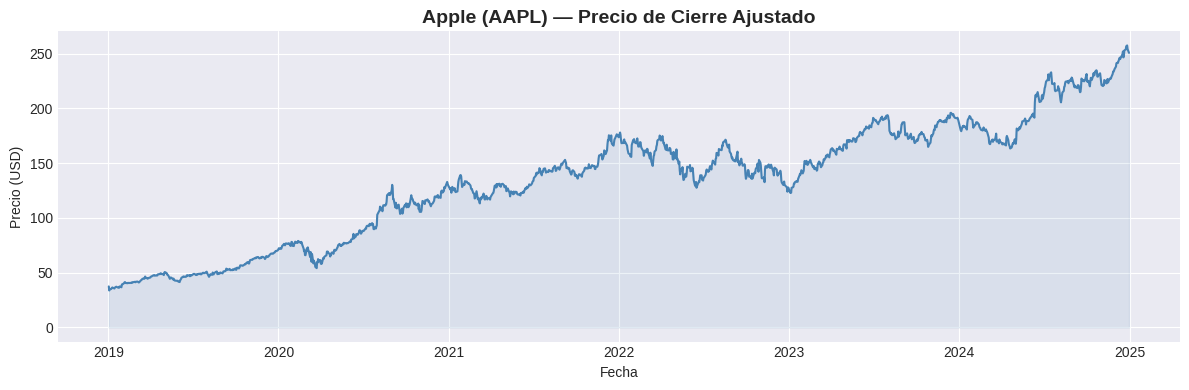

In [6]:
# ─── Gráfica rápida del precio de cierre ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(aapl.index, aapl['Close'].squeeze(), color='steelblue', linewidth=1.5)
ax.fill_between(aapl.index, aapl['Close'].squeeze(), alpha=0.1, color='steelblue')
ax.set_title('Apple (AAPL) — Precio de Cierre Ajustado', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
plt.tight_layout()
plt.show()

---
## 📡 Parte 4: Descargar VARIAS acciones a la vez

Cuando pasas una lista de tickers, `yf.download()` regresa un DataFrame con **MultiIndex** en las columnas — es decir, dos niveles: `(tipo_precio, ticker)`.

Lo más práctico es extraer solo el precio de cierre (`Close`) para trabajar con un DataFrame limpio.

In [7]:
# ─── Lista de tickers a descargar ────────────────────────────────────────────
TICKERS = ["AAPL", "MSFT", "SPY", "WALMEX.MX", "GC=F"]
# Apple, Microsoft, ETF S&P500, Walmart México, Oro

print(f"⏳ Descargando {len(TICKERS)} activos...")

datos = yf.download(
    tickers     = TICKERS,
    start       = "2020-01-01",
    end         = "2024-12-31",
    auto_adjust = True,
    progress    = False
)

print(f"✅ Descarga completa. Dimensiones brutas: {datos.shape}")

⏳ Descargando 5 activos...
✅ Descarga completa. Dimensiones brutas: (1293, 25)


In [8]:
# ─── Extraer solo precios de cierre ──────────────────────────────────────────
# Esta es la forma estándar de trabajar con múltiples activos

precios = datos['Close'].copy()
precios.index.name = 'Fecha'

print("DataFrame de precios de cierre:")
print(f"   → Dimensiones: {precios.shape}  ({precios.shape[0]} días × {precios.shape[1]} activos)")
print()
precios.tail()

DataFrame de precios de cierre:
   → Dimensiones: (1293, 5)  (1293 días × 5 activos)



Ticker,AAPL,GC=F,MSFT,SPY,WALMEX.MX
Fecha,,,,,
2024-12-23,253.6494,2612.3000,431.0789,586.1866,54.8025
2024-12-24,256.5609,2620.0000,435.1197,592.7021,54.7442
2024-12-26,257.3756,2638.8000,433.9114,592.7416,54.5789
2024-12-27,253.9674,2617.2000,426.4041,586.5021,53.3928
2024-12-30,250.5989,2606.1001,420.7587,579.8091,52.7706


In [10]:
# ─── Revisar valores faltantes ────────────────────────────────────────────────
# Es normal que haya NaN: la BMV y NYSE no tienen exactamente los mismos
# días de asueto, así que algunas fechas tendrán datos de unos activos pero no de otros

print("🔍 Valores faltantes por activo:")
nulos = precios.isnull().sum()
pct_nulos = (precios.isnull().mean() * 100).round(2)

resumen_nulos = pd.DataFrame({'NaN count': nulos, '% del total': pct_nulos})
print(resumen_nulos)
print()
print("Los NaN de WALMEX.MX son normales: la BMV tiene días festivos diferentes a NYSE/NASDAQ")

🔍 Valores faltantes por activo:
           NaN count  % del total
Ticker                           
AAPL              36       2.7800
GC=F              36       2.7800
MSFT              36       2.7800
SPY               36       2.7800
WALMEX.MX         35       2.7100

Los NaN de WALMEX.MX son normales: la BMV tiene días festivos diferentes a NYSE/NASDAQ


In [12]:
# ─── Estrategias para manejar los NaN ────────────────────────────────────────

# OPCIÓN A: Forward fill — propagar el último precio conocido hacia adelante
# (es el estándar en finanzas: "si no hubo trading, el precio no cambió")
precios_ffill = precios.ffill()

# OPCIÓN B: Eliminar filas con cualquier NaN (pierdes días de NYSE por asuetos BMV)
precios_dropna = precios.dropna()

# OPCIÓN C: Eliminar filas donde TODOS son NaN (fines de semana, festivos globales)
precios_clean = precios.dropna(how='all')

print("📊 Comparación de estrategias:")
print(f"   Original:                {len(precios):,} filas")
print(f"   Forward fill (ffill):    {len(precios_ffill):,} filas")
print(f"   dropna() completo:       {len(precios_dropna):,} filas")
print(f"   dropna(how='all'):       {len(precios_clean):,} filas")

# Usaremos forward fill para el análisis
precios = precios_ffill.copy()
print("\n✅ Usando forward fill como estrategia de limpieza")

📊 Comparación de estrategias:
   Original:                1,293 filas
   Forward fill (ffill):    1,293 filas
   dropna() completo:       1,293 filas
   dropna(how='all'):       1,293 filas

✅ Usando forward fill como estrategia de limpieza


---
## 📡 Parte 5: Datos adicionales con el objeto `Ticker`

Además de precios históricos, `yfinance` permite obtener información detallada de cada empresa usando el objeto `yf.Ticker()`.

In [ ]:
# ─── Crear un objeto Ticker ───────────────────────────────────────────────────
apple = yf.Ticker("AAPL")

# Información general de la empresa
info = apple.info

campos_interes = [
    'longName', 'sector', 'industry', 'country',
    'marketCap', 'trailingPE', 'dividendYield',
    'fiftyTwoWeekHigh', 'fiftyTwoWeekLow', 'currency'
]

print("🏢 Información de Apple Inc. (AAPL):")
print("-" * 45)
for campo in campos_interes:
    valor = info.get(campo, 'No disponible')
    if campo == 'marketCap' and isinstance(valor, (int, float)):
        valor = f"${valor/1e12:.2f} Billones USD"
    elif campo == 'dividendYield' and isinstance(valor, (int, float)):
        valor = f"{valor*100:.2f}%"
    print(f"   {campo:<22}: {valor}")

In [ ]:
# ─── Historial de dividendos ──────────────────────────────────────────────────
dividendos = apple.dividends

if len(dividendos) > 0:
    print(f"💰 Últimos 8 dividendos pagados por Apple:")
    print(dividendos.tail(8).to_frame())
else:
    print("Este activo no paga dividendos")

In [ ]:
# ─── Diferentes intervalos de tiempo ─────────────────────────────────────────
# A veces necesitas datos semanales o mensuales en vez de diarios

print("📅 Ejemplos de intervalos disponibles:")
print()

intervalos = {
    'Diario':   '1d',
    'Semanal':  '1wk',
    'Mensual':  '1mo',
}

for nombre, intervalo in intervalos.items():
    df = yf.download("SPY", period="1y", interval=intervalo, auto_adjust=True, progress=False)
    print(f"   {nombre} (interval='{intervalo}'): {len(df)} filas")

---
## 💾 Parte 6: Guardar y cargar los datos

Una buena práctica es guardar los datos descargados para no depender de internet cada vez que abres el notebook.

In [ ]:
# ─── Guardar como CSV ─────────────────────────────────────────────────────────
precios.to_csv("precios_portafolio.csv")
print("💾 Datos guardados en: precios_portafolio.csv")

# ─── Cargar el CSV guardado ───────────────────────────────────────────────────
precios_cargados = pd.read_csv(
    "precios_portafolio.csv",
    index_col = "Fecha",     # La columna Fecha como índice
    parse_dates = True       # Convertir a tipo datetime automáticamente
)

print(f"✅ CSV cargado correctamente: {precios_cargados.shape}")
precios_cargados.head(3)

---
## 🗂️ Parte 7: Búsqueda de tickers — ¿Cómo encontrar el correcto?

### Método 1: Yahoo Finance directamente
1. Ve a **[finance.yahoo.com](https://finance.yahoo.com)**
2. Escribe el nombre de la empresa en la barra de búsqueda
3. El ticker aparece junto al nombre en los resultados

### Método 2: Desde Python con `yfinance`

In [ ]:
# ─── Verificar si un ticker existe y obtener su nombre ───────────────────────

def verificar_ticker(ticker):
    """Verifica si un ticker existe y muestra información básica."""
    try:
        t = yf.Ticker(ticker)
        nombre = t.info.get('longName') or t.info.get('shortName', 'Desconocido')
        moneda = t.info.get('currency', '?')
        sector = t.info.get('sector', 'ETF/Commodity/Crypto')
        # Verificar que tenga datos
        hist = t.history(period='5d')
        if len(hist) > 0:
            precio_actual = hist['Close'].iloc[-1]
            print(f"   ✅ {ticker:<15} | {nombre:<35} | {moneda} {precio_actual:.2f} | {sector}")
        else:
            print(f"   ❌ {ticker:<15} | Sin datos disponibles")
    except Exception as e:
        print(f"   ❌ {ticker:<15} | Error: {e}")

tickers_a_verificar = ["AAPL", "SPY", "WALMEX.MX", "BTC-USD", "GC=F", "TICKER_FALSO"]

print(f"🔍 Verificando tickers:")
print(f"   {'Ticker':<15} | {'Nombre':<35} | {'Precio':<12} | Sector")
print("   " + "-" * 80)
for t in tickers_a_verificar:
    verificar_ticker(t)

---
## ⚠️ Parte 8: Errores comunes y cómo resolverlos

| Problema | Causa | Solución |
|----------|-------|----------|
| DataFrame vacío `(0, 6)` | Ticker incorrecto o sin datos en ese período | Verifica el ticker en Yahoo Finance |
| Muchos `NaN` en acciones mexicanas | BMV tiene festivos distintos a NYSE | Usa `.ffill()` |
| `ModuleNotFoundError: yfinance` | No está instalado | Corre `!pip install yfinance` |
| Datos solo hasta hace unos días | Yahoo Finance tiene delay de ~15 min | Normal, usa `end=datetime.today()` |
| `JSONDecodeError` o timeout | Problema de conexión a internet | Reintenta en unos minutos |
| Columnas con MultiIndex confusos | Descarga de múltiples tickers | Usa `datos['Close']` para simplificar |

In [ ]:
# ─── Descarga robusta con manejo de errores ───────────────────────────────────

def descargar_datos_seguro(tickers, start, end):
    """
    Descarga precios de cierre con manejo de errores.
    Retorna un DataFrame limpio con forward fill aplicado.
    """
    try:
        datos = yf.download(
            tickers     = tickers,
            start       = start,
            end         = end,
            auto_adjust = True,
            progress    = False
        )
        
        if datos.empty:
            raise ValueError("No se obtuvieron datos. Verifica los tickers y fechas.")
        
        # Extraer precios de cierre
        if isinstance(tickers, list) and len(tickers) > 1:
            precios = datos['Close'].copy()
        else:
            precios = datos[['Close']].copy()
            precios.columns = [tickers] if isinstance(tickers, str) else tickers
        
        # Limpiar
        precios = precios.ffill().dropna(how='all')
        
        print(f"✅ Descarga exitosa: {precios.shape[0]} días × {precios.shape[1]} activos")
        print(f"   Período: {precios.index[0].date()} → {precios.index[-1].date()}")
        
        return precios
    
    except Exception as e:
        print(f"❌ Error en la descarga: {e}")
        return None


# Prueba de la función
mi_portafolio = descargar_datos_seguro(
    tickers = ["SPY", "QQQ", "GLD", "AMXL.MX"],
    start   = "2022-01-01",
    end     = "2024-12-31"
)

if mi_portafolio is not None:
    mi_portafolio.tail(3)

---
## ✅ Resumen: Lo que aprendiste

```python
import yfinance as yf

# 1. Descargar una acción
datos = yf.download("AAPL", start="2020-01-01", end="2024-12-31", auto_adjust=True)

# 2. Descargar varias acciones y extraer cierre
datos = yf.download(["AAPL", "MSFT", "SPY"], start="2020-01-01", end="2024-12-31", auto_adjust=True)
precios = datos['Close'].ffill()

# 3. Información de empresa
info = yf.Ticker("AAPL").info

# 4. Guardar / cargar
precios.to_csv("datos.csv")
precios = pd.read_csv("datos.csv", index_col="Fecha", parse_dates=True)
```

---
### 🚀 Siguiente paso
Abre el notebook **`02_portafolio_conservador.ipynb`** donde aplicarás todo esto para analizar un portafolio de inversión real con gráficas interactivas.